# CMRM Assignment No. 2

In [1]:
import os
import librosa
import scipy
import sklearn # pip install sklearn
import numpy as np
import pandas as pd # pip install pandas
import matplotlib.pyplot as plt
import IPython.display as ipd
from tqdm import tqdm # pip install tqdm
from sklearn.linear_model import LogisticRegression
from mutagen.easyid3 import EasyID3 # pip install mutagen

## Question 1

In [ ]:
train_path = "data/train"
test_path = "data/test"


# Train set
fake_path = os.path.join(train_path, "fake")
real_path = os.path.join(train_path, "real")


fake_train  = [
    i for i in os.listdir(fake_path)
    if not i.startswith(".")
]

fake_train.sort()

# Print the number of files
print("Number of fake tracks in the train set:", len(fake_train))



real_train = [
    i for i in os.listdir(real_path)
    if not i.startswith(".")
]

# Print the number of files
print("Number of real tracks in the train set:", len(real_train))



# Test set
test_set = [
    i for i in os.listdir(test_path)
    if not i.startswith(".")
]

# Print the number of files
print("Number of tracks in the test set:", len(test_set))

Number of fake tracks in the train set: 485
Number of real tracks in the train set: 485
Number of tracks in the test set: 515


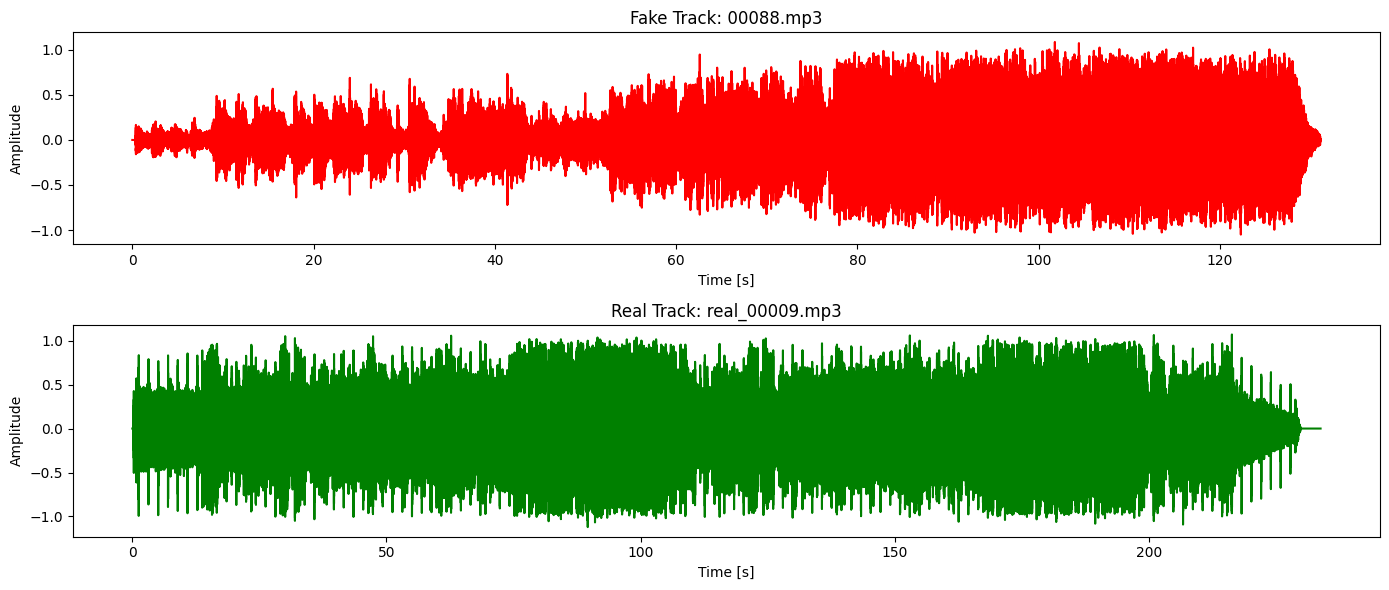

In [3]:
#load and plot first fake and real file
Fs = 22050

fake_firstfile_path = os.path.join(fake_path, fake_train[0])
real_firstfile_path = os.path.join(real_path, real_train[0])
fake_audio, Fs = librosa.load(fake_firstfile_path, sr=Fs)
real_audio, Fs = librosa.load(real_firstfile_path, sr=Fs)
timeaxis_fake = np.arange(len(fake_audio)) / Fs
timeaxis_real = np.arange(len(real_audio)) / Fs

plt.figure(figsize=(14, 6))

plt.subplot(2, 1, 1)
plt.plot(timeaxis_fake, fake_audio, color='r')
plt.title(f"Fake Track: {fake_train[0]}")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")

plt.subplot(2, 1, 2)
plt.plot(timeaxis_real, real_audio, color='g')
plt.title(f"Real Track: {real_train[0]}")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

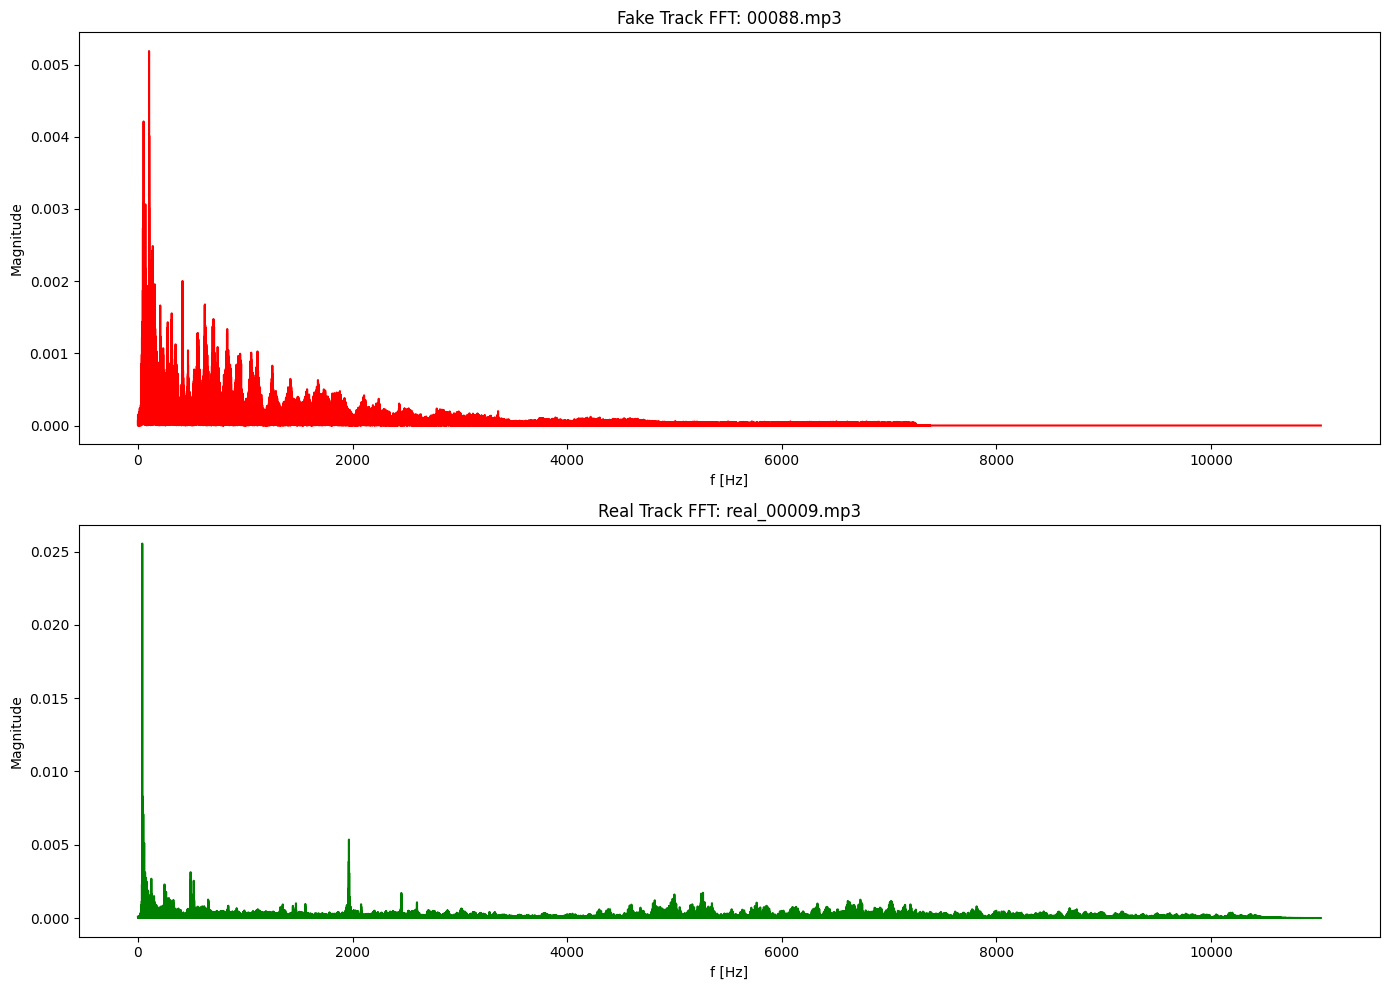

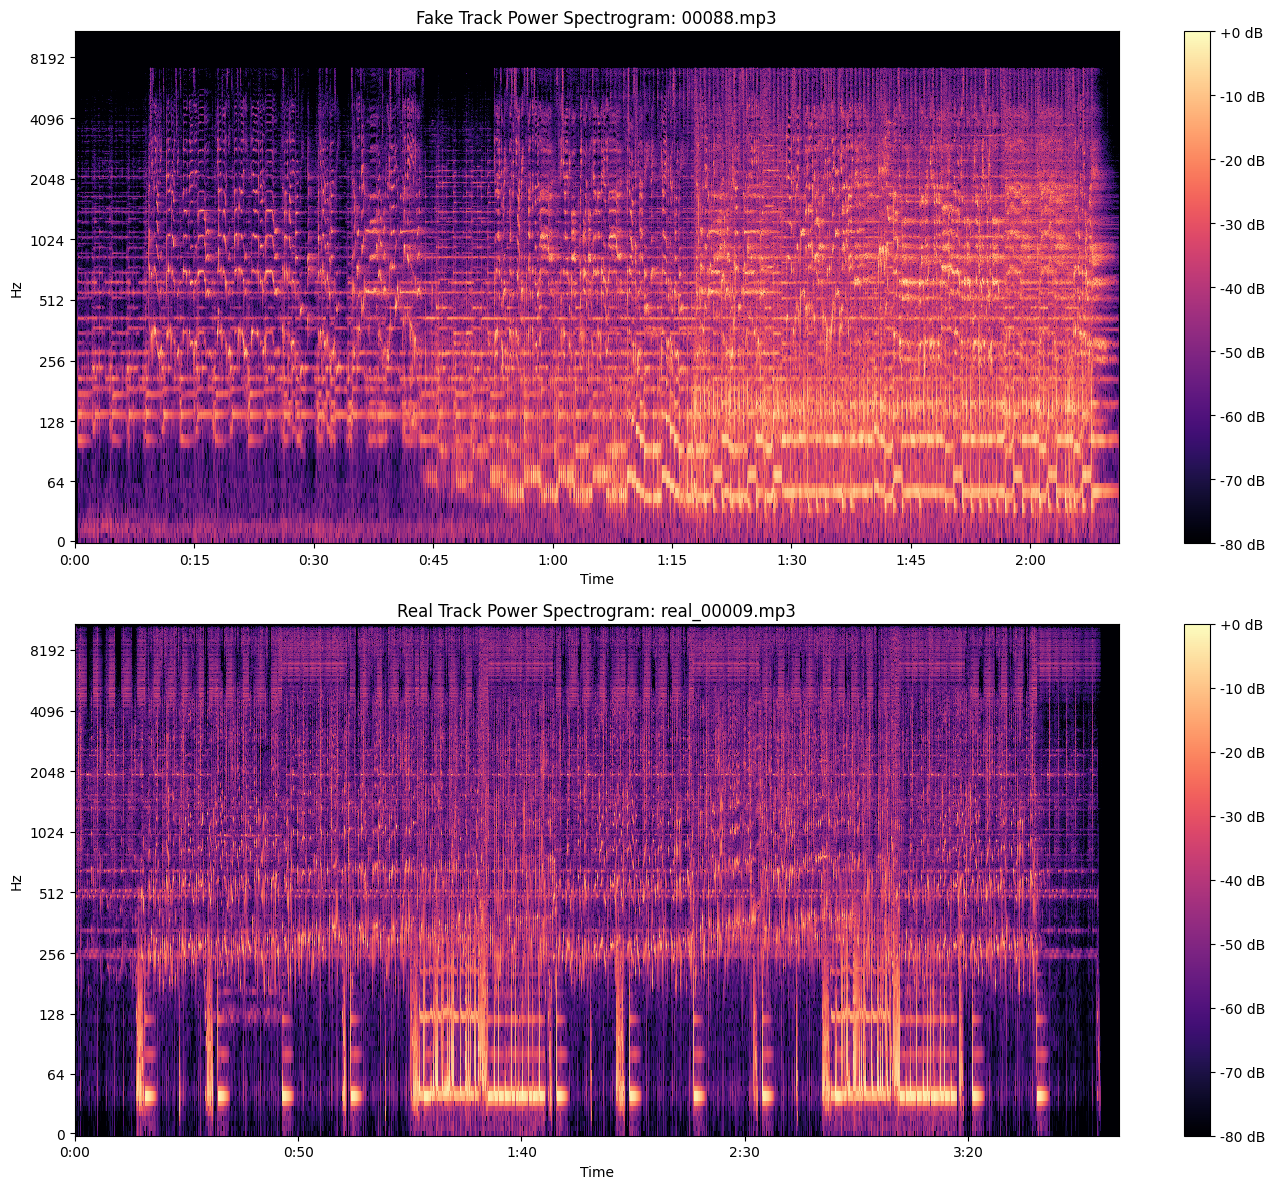

In [4]:
# FFT
def compute_fft(audio, Fs):
 N = len(audio)
 fft_vals = np.fft.fft(audio)
 fft_vals = fft_vals[:N // 2]  # Take only positive frequencies
 fft_mag = np.abs(fft_vals) / N
 freq_axis = np.linspace(0, Fs / 2, N // 2)
 return freq_axis, fft_mag

freq_fake, mag_fake = compute_fft(fake_audio, Fs)
freq_real, mag_real = compute_fft(real_audio, Fs)

# Plot
plt.figure(figsize=(14, 10))

plt.subplot(2, 1, 1)
plt.plot(freq_fake, mag_fake, color='r')
plt.title(f"Fake Track FFT: {fake_train[0]}")
plt.xlabel("f [Hz]")
plt.ylabel("Magnitude")

plt.subplot(2, 1, 2)
plt.plot(freq_real, mag_real, color='g')
plt.title(f"Real Track FFT: {real_train[0]}")
plt.xlabel("f [Hz]")
plt.ylabel("Magnitude")

plt.tight_layout()
plt.show()


# STFT
N = 4096
H = 1024

stft_fake = librosa.stft(fake_audio, n_fft=N, hop_length=H, window='hann')
stft_real = librosa.stft(real_audio, n_fft=N, hop_length=H, window='hann')

power_fake = np.abs(stft_fake)**2
power_real = np.abs(stft_real)**2
power_fake_db = librosa.power_to_db(power_fake, ref=np.max)
power_real_db = librosa.power_to_db(power_real, ref=np.max)

plt.figure(figsize=(14, 12))

plt.subplot(2, 1, 1)
librosa.display.specshow(power_fake_db, sr=Fs, hop_length=H, x_axis='time', y_axis='log', cmap='magma')
plt.colorbar(format='%+2.0f dB')
plt.title(f"Fake Track Power Spectrogram: {fake_train[0]}")

plt.subplot(2, 1, 2)
librosa.display.specshow(power_real_db, sr=Fs, hop_length=H, x_axis='time', y_axis='log', cmap='magma')
plt.colorbar(format='%+2.0f dB')
plt.title(f"Real Track Power Spectrogram: {real_train[0]}")

plt.tight_layout()
plt.show()

## Question 2

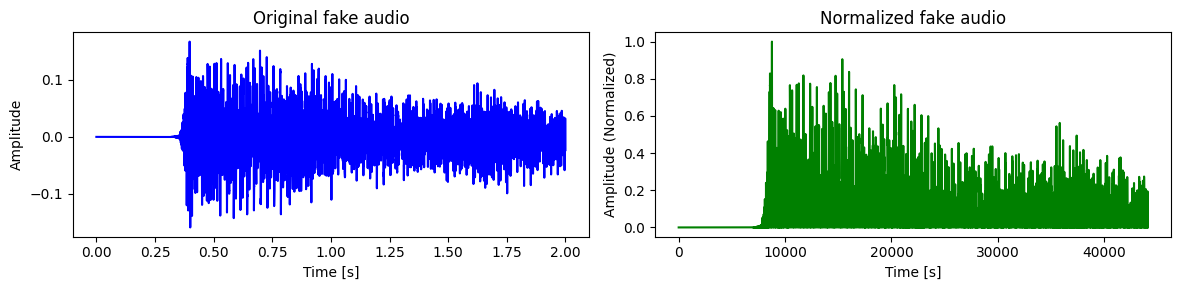

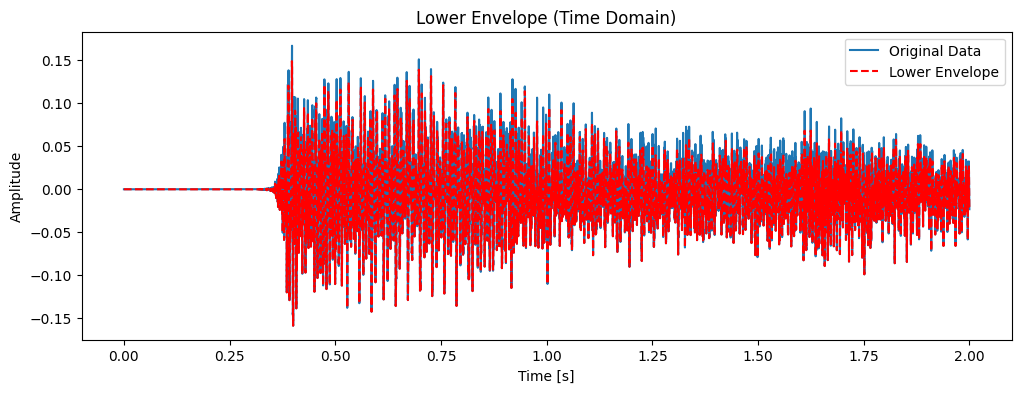

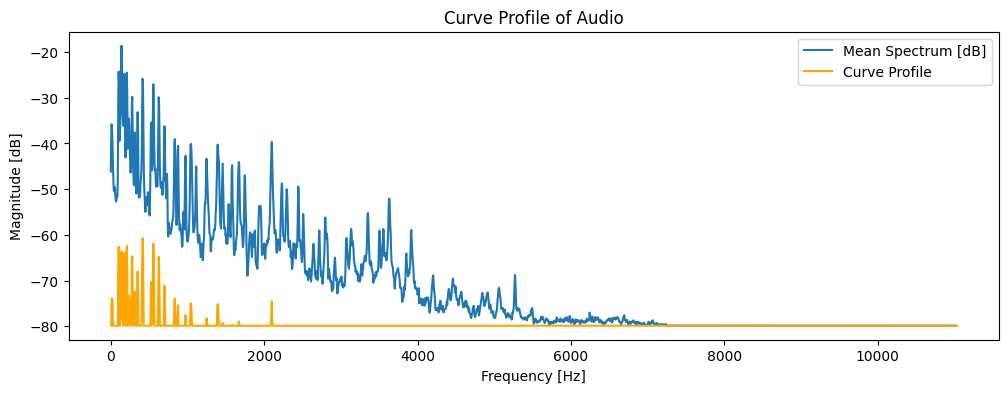

In [5]:
#test utils functions
from utils import lower_envelope, max_normalise, curve_profile

fake_audio_cut = fake_audio[:2*Fs]

#max_normalise
normalized_fake_audio = max_normalise(fake_audio_cut, max_dB=5)
t = np.arange(len(fake_audio_cut)) / Fs
plt.figure(figsize=(12, 3))
plt.subplot(1, 2, 1)
plt.plot(t, fake_audio_cut, color='blue')
plt.title('Original fake audio')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.subplot(1, 2, 2)
plt.plot(normalized_fake_audio, color='green')
plt.title('Normalized fake audio')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude (Normalized)')
plt.tight_layout()
plt.show()

#lower_envelope
idx, hull = lower_envelope(fake_audio_cut, area=10)
t = np.arange(len(fake_audio_cut)) / Fs
plt.figure(figsize=(12, 4))
plt.plot(t, fake_audio_cut, label='Original Data')
plt.plot(t[idx], hull, label='Lower Envelope', linestyle='--', color='red')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.title('Lower Envelope (Time Domain)')
plt.legend()
plt.show()

#curve_profile
S = np.abs(librosa.stft(fake_audio_cut, n_fft=N, hop_length=H))
S_db = librosa.amplitude_to_db(S, ref=np.max)
freqs = librosa.fft_frequencies(sr=Fs, n_fft=N)
c = np.mean(S_db, axis=1)
x_profile, profile = curve_profile(freqs, c, f_range = [0, 16000])

plt.figure(figsize=(12, 4))
plt.plot(freqs, c, label='Mean Spectrum [dB]')
plt.plot(x_profile, profile + np.min(c), label='Curve Profile', color='orange')  
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude [dB]')
plt.title('Curve Profile of Audio')
plt.legend()
plt.show()

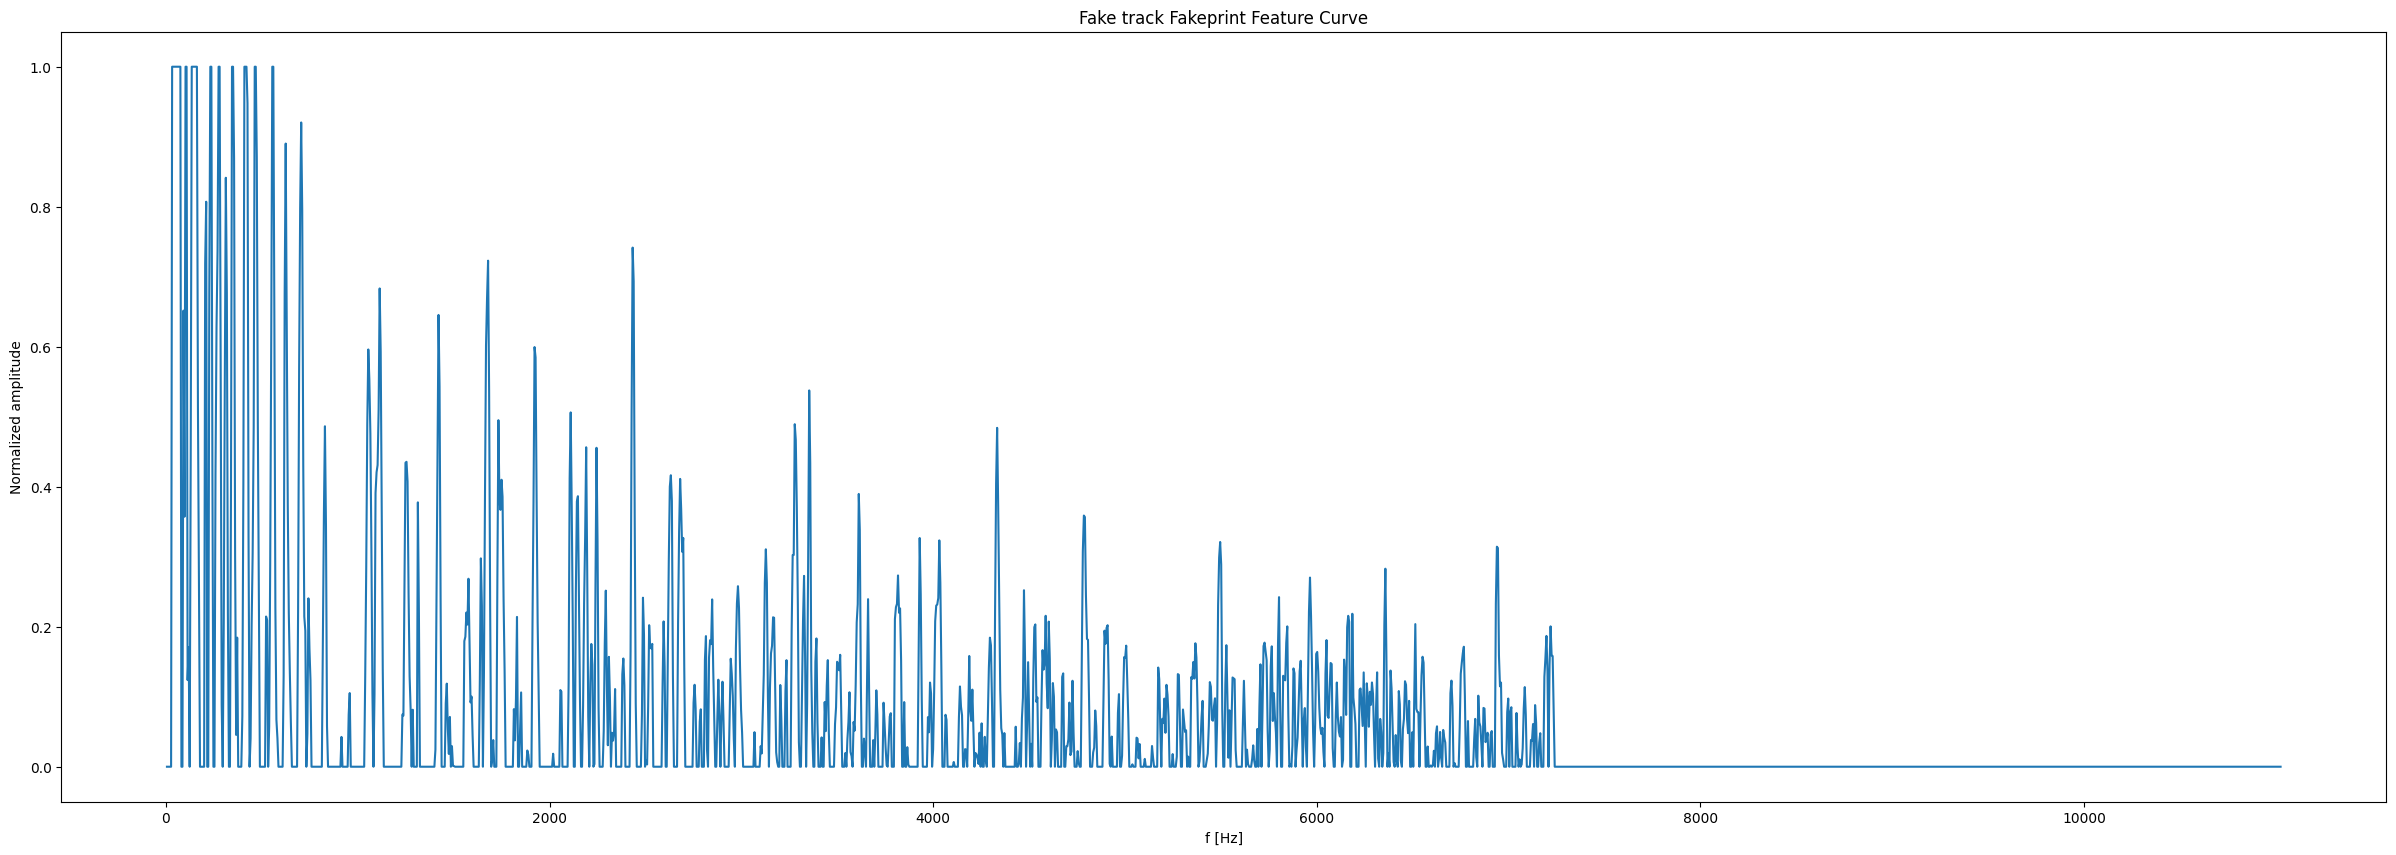

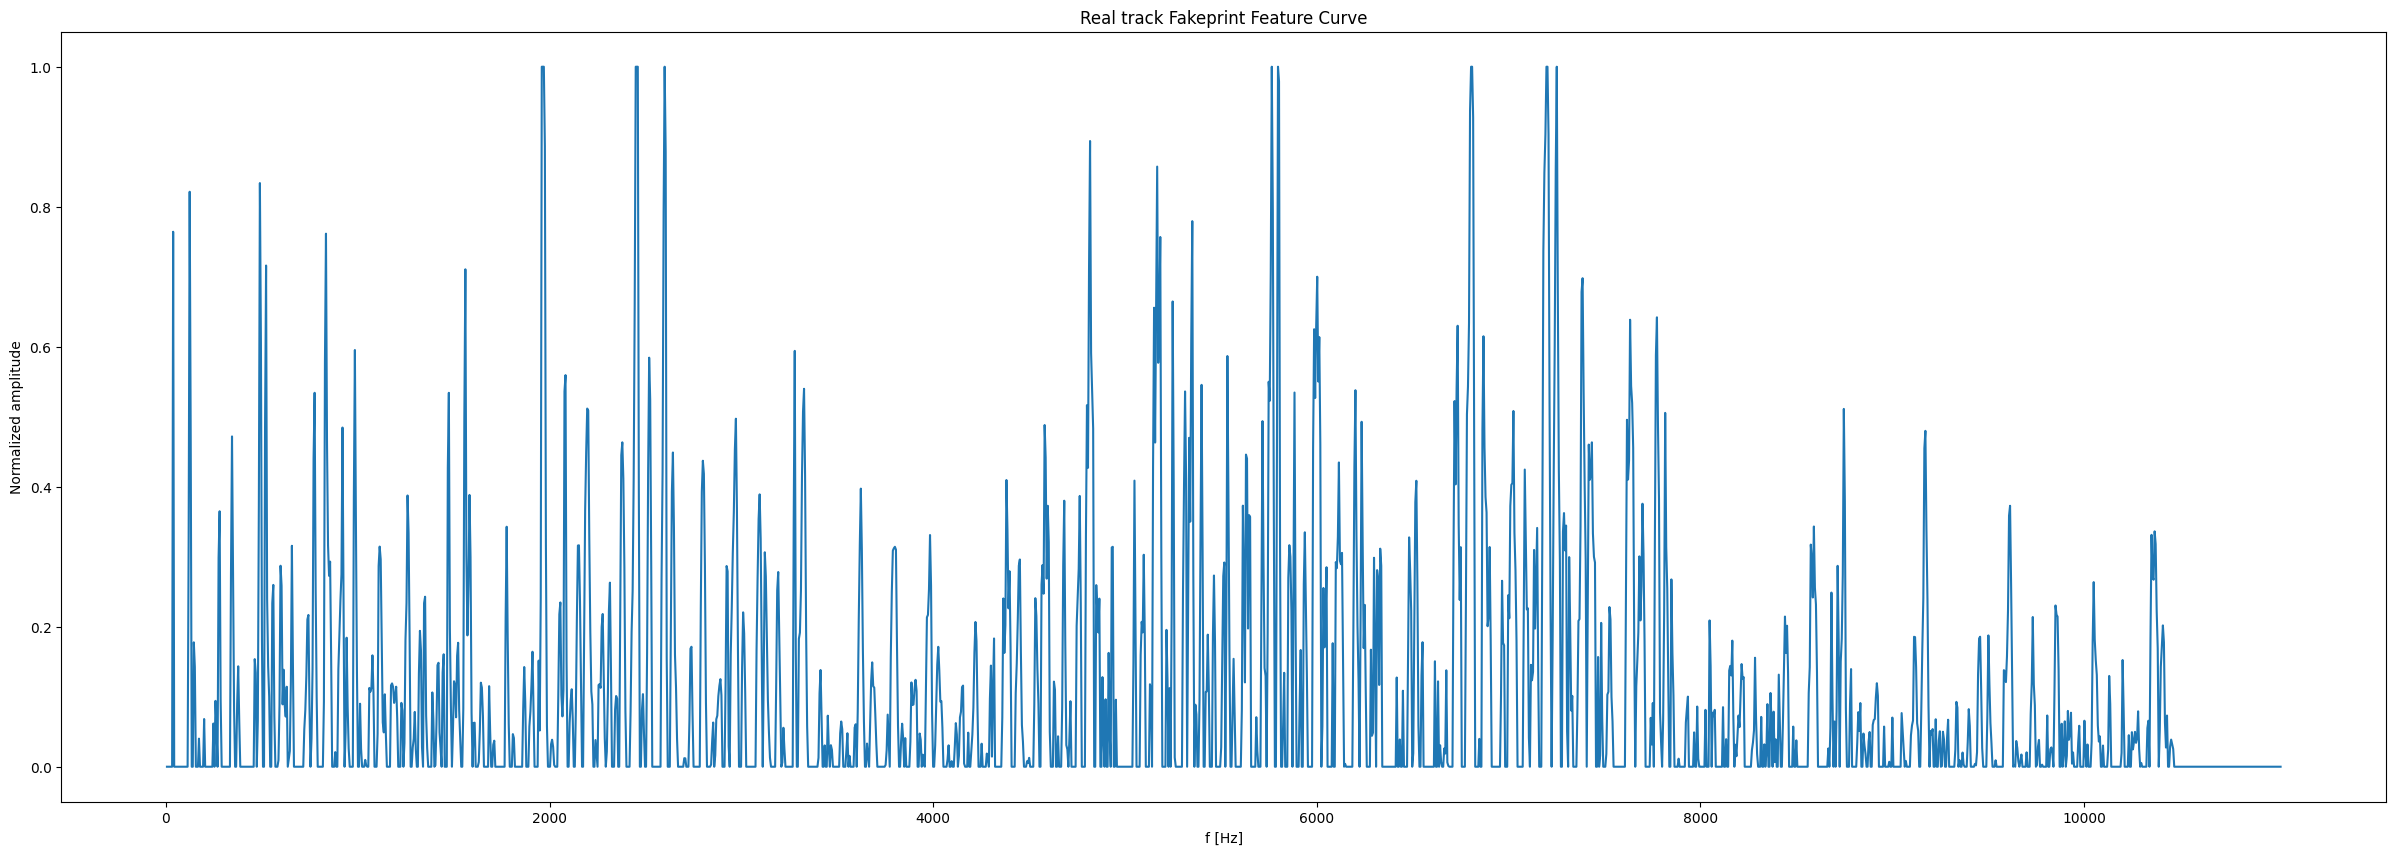

In [6]:
# Test fakeprint

def fakeprint(stft, f_range=[0, 16000], fs=22050):
    """ 
    Compute the fakeprint feature from an STFT representation.

    Args:
        stft: 2D STFT spectrogram (frequency bins × time frames).
        f_range: Frequency range [min_freq, max_freq] over which the
                 curve profile is computed.
        fs: Sampling rate of the original audio signal.

    Returns:
        fp_curve: Normalized fakeprint feature curve extracted from the
                  averaged spectral profile.
    """ 

    power_stft = np.abs(stft)**2
    
    # Step 1: Compute mean across time frames
    mean_spectrum = np.mean(power_stft, axis=1)

    ms_db = librosa.power_to_db(mean_spectrum, ref=np.max)
    
    # Step 2: Construct the frequency axis
    x_freq = np.linspace(0, fs / 2, len(ms_db))
    
    # Step 3: Compute the curve profile within the frequency range
    x_, profile = curve_profile(x_freq, ms_db, f_range)
    
    # Step 4: Normalize the profile
    fp_curve = max_normalise(profile)
    
    return x_, fp_curve



x_, fp_curve_fake = fakeprint(stft_fake, f_range=[0, 16000], fs=Fs)
x_, fp_curve_real = fakeprint(stft_real, f_range=[0, 16000], fs=Fs)

plt.figure(figsize=(30, 10))
plt.plot(x_, fp_curve_fake)
plt.xlabel("f [Hz]")
plt.ylabel("Normalized amplitude")
plt.title("Fake track Fakeprint Feature Curve")
#plt.xscale('log')
plt.show()

plt.figure(figsize=(30, 10))
plt.plot(x_, fp_curve_real)
plt.xlabel("f [Hz]")
plt.ylabel("Normalized amplitude")
plt.title("Real track Fakeprint Feature Curve")
#plt.xscale('log')
plt.show()

## Question 3

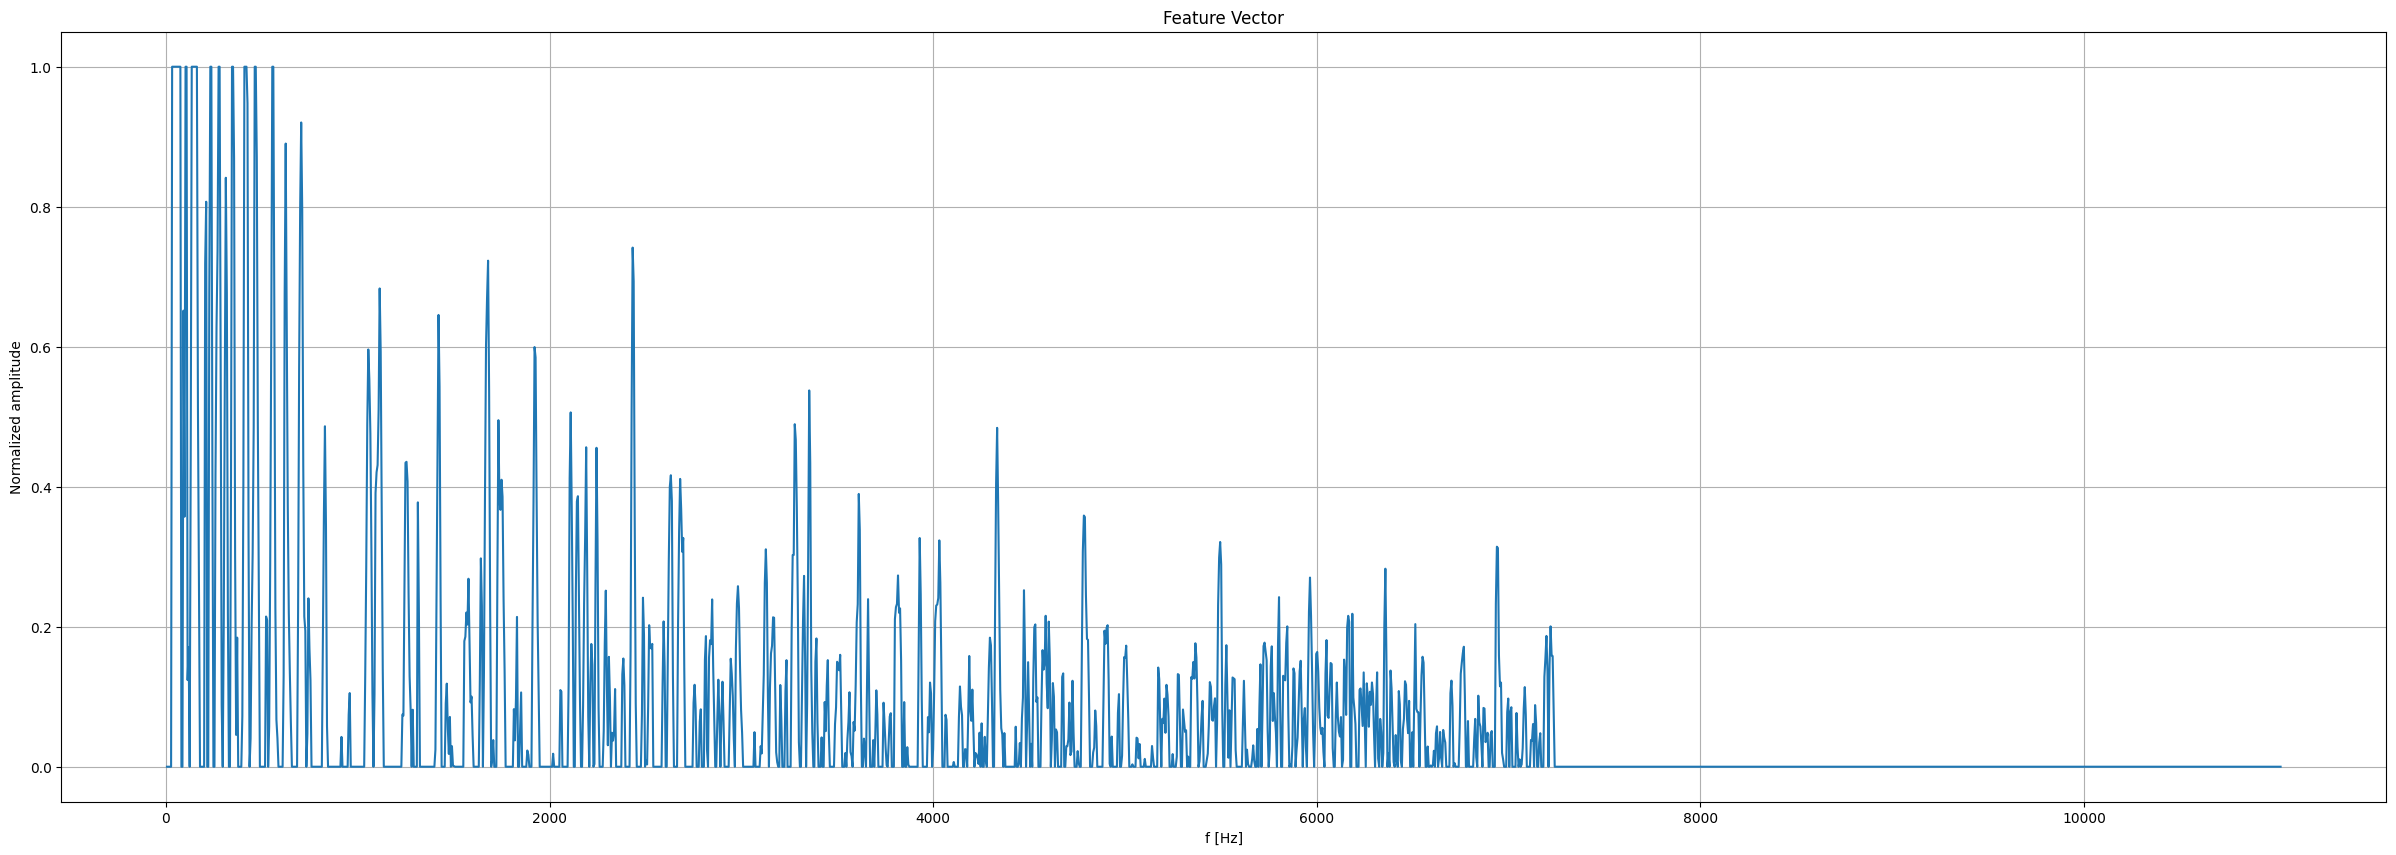

In [ ]:
def compute_feature_vector(filename, Fs, N=4096, H=1024):
    """
    Compute fakeprint feature vector given only filename.
    The function determines the folder based on the filename or dataset structure.
    """
    
    train_folder = "data/train"
    test_folder = "data/test"

    # Decide which folder the file belongs to
    if os.path.exists(os.path.join(train_folder, 'fake', filename)):
        folder = os.path.join(train_folder, 'fake')
    elif os.path.exists(os.path.join(train_folder, 'real', filename)):
        folder = os.path.join(train_folder, 'real')
    elif os.path.exists(os.path.join(test_folder, filename)):
        folder = test_folder
    else:
        raise FileNotFoundError(f"File {filename} not found in any known folder.")

    file_path = os.path.join(folder, filename)
    audio, sr = librosa.load(file_path, sr=Fs)

    stft = librosa.stft(audio, n_fft=N, hop_length=H, window='hann')
    
    x_, f_vector = fakeprint(stft, f_range=[0, 16000], fs=Fs)

    return x_, f_vector


#test feature_vector
x_, feature_vector = compute_feature_vector("00088.mp3", Fs=Fs)

plt.figure(figsize=(30, 10))
plt.plot(x_, feature_vector)
plt.title("Feature Vector")
plt.xlabel("f [Hz]")
plt.ylabel("Normalized amplitude")
plt.grid(True)
plt.show()

In [ ]:
# Define labels_dict
labels_dict = {
    0: 'fake',
    1: 'real'
}

Fs = 22050

# Compute feature vector for train
training_main_folder = "data/train"
train_fvector = []
train_labels = []

for root, dirs, files in os.walk(training_main_folder):
    
    mp3_files = [f for f in files if f.endswith(".mp3")]

    folder_name = os.path.basename(root)

    if folder_name == 'fake':
        label = 0
    elif folder_name == 'real':
        label = 1
    else:
        continue   

    for filename in tqdm(mp3_files, desc=f"Processing files in {root}"):
        
        _, f_vector = compute_feature_vector(filename, Fs)
        train_fvector.append(f_vector)
        train_labels.append(label)

for i, (f_vector, label) in enumerate(zip(train_fvector, train_labels)):
    print(f"File {i}: shape = {f_vector.shape}, Label = {label}")



# Compute feature vector for test
folder_test = "data/test"
test_fvector = []

test_files = [f for f in os.listdir(folder_test) if f.endswith(".mp3")]


for filename in tqdm(test_files, desc="Processing test files"):
 
    _, f_vector = compute_feature_vector(filename, Fs)
    test_fvector.append(f_vector)

Processing files in C:\Users\anton\Desktop\homework2\sonics\train\fake: 100%|████████| 485/485 [07:16<00:00,  1.11it/s]
Processing files in C:\Users\anton\Desktop\homework2\sonics\train\real: 100%|████████| 485/485 [25:29<00:00,  3.15s/it]


File 0: shape = (2048,), Label = 0
File 1: shape = (2048,), Label = 0
File 2: shape = (2048,), Label = 0
File 3: shape = (2048,), Label = 0
File 4: shape = (2048,), Label = 0
File 5: shape = (2048,), Label = 0
File 6: shape = (2048,), Label = 0
File 7: shape = (2048,), Label = 0
File 8: shape = (2048,), Label = 0
File 9: shape = (2048,), Label = 0
File 10: shape = (2048,), Label = 0
File 11: shape = (2048,), Label = 0
File 12: shape = (2048,), Label = 0
File 13: shape = (2048,), Label = 0
File 14: shape = (2048,), Label = 0
File 15: shape = (2048,), Label = 0
File 16: shape = (2048,), Label = 0
File 17: shape = (2048,), Label = 0
File 18: shape = (2048,), Label = 0
File 19: shape = (2048,), Label = 0
File 20: shape = (2048,), Label = 0
File 21: shape = (2048,), Label = 0
File 22: shape = (2048,), Label = 0
File 23: shape = (2048,), Label = 0
File 24: shape = (2048,), Label = 0
File 25: shape = (2048,), Label = 0
File 26: shape = (2048,), Label = 0
File 27: shape = (2048,), Label = 0
Fi

Processing test files: 100%|█████████████████████████████████████████████████████████| 515/515 [07:31<00:00,  1.14it/s]


In [9]:
# Train regressor
X_train = np.stack(train_fvector)  
y_train = np.array(train_labels)   

print(f"Feature matrix shape: {X_train.shape}")
print(f"Labels shape: {y_train.shape}")

clf = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)

clf.fit(X_train, y_train)

threshold = 0.2  # set custom threshold
y_prob_train = clf.predict_proba(X_train)[:, 1]  
y_pred_train = (y_prob_train > threshold).astype(int)

Feature matrix shape: (970, 2048)
Labels shape: (970,)


Training accuracy: 100.00%


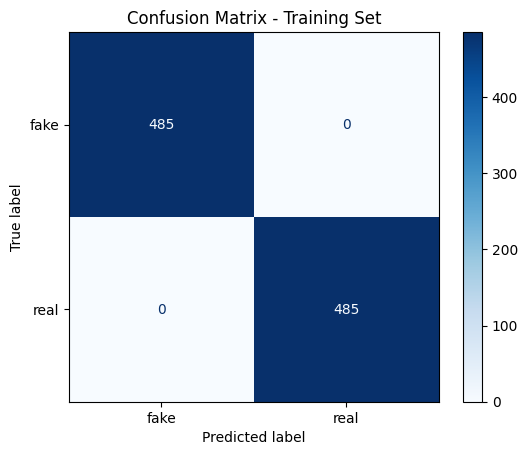

In [10]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

train_acc = accuracy_score(y_train, y_pred_train)
print(f"Training accuracy: {train_acc*100:.2f}%")

cm = confusion_matrix(y_train, y_pred_train)
disp = ConfusionMatrixDisplay(cm, display_labels=['fake', 'real'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Training Set")
plt.show()

## Question 4

In [11]:
# Compute prediction for the test set
X_test = np.stack(test_fvector)  

y_prob_test = clf.predict_proba(X_test)[:, 1] 
y_pred_test = (y_prob_test > threshold).astype(int)


real_tracks = []

for filename, pred_label in zip(test_files, y_pred_test):
    if pred_label == 1:  
        real_tracks.append(filename)


print("The real tracks are: \n:")
for track in real_tracks:
    print(track)

The real tracks are: 
:
38110.mp3
38246.mp3
38276.mp3
40219.mp3
42833.mp3
47304.mp3
51890.mp3
52180.mp3
53966.mp3
53969.mp3
54100.mp3


In [ ]:
# Find password

folder_test = "data/test"

psw = 0

print("Dates found in real tracks:")

for track in real_tracks:
    file_path = os.path.join(folder_test, track)
    try:
        audio = EasyID3(file_path)
        date_str = audio['date'][0]  
        print(f"{track}: {date_str}")
        psw += int(date_str)  
    except KeyError:
        continue
    except ValueError:
        continue

print(f'The password is: {psw}')

Dates found in real tracks:
51890.mp3: 2001
52180.mp3: 1789
53966.mp3: 0476
54100.mp3: 1492
The password is: 5758


In [ ]:
csv_file = "data/ground_truth/ground_truth.csv"
folder_test = "data/test"


df_gt = pd.read_csv(csv_file)

num_rows, num_cols = df_gt.shape
print(f"Number of rows: {num_rows}")
print(f"Number of columns: {num_cols}")
print("Column names:")
print(df_gt.columns.tolist())

print("\nGround truth CSV head:")
print(df_gt.head())

test_files_clean = [os.path.basename(f) for f in os.listdir(folder_test) if f.endswith(".mp3")]
test_ids = [int(f.split(".")[0]) for f in test_files_clean]  #convert "27679.mp3" to 27679

y_test_aligned = []
valid_test_files = []

for f_id, f_name in zip(test_ids, test_files_clean):
    match = df_gt.loc[df_gt['id'] == f_id, 'label']
    if not match.empty:
        y_test_aligned.append(1 if match.values[0]=='real' else 0)
        valid_test_files.append(f_name)

X_test = np.stack(test_fvector)  # feature matrix
y_prob_test = clf.predict_proba(X_test)[:, 1]

y_pred_aligned = []
for f_name in valid_test_files:
    idx = test_files_clean.index(f_name)
    y_pred_aligned.append(int(y_prob_test[idx] > threshold))



# Verify if your items are real
print("\nTracks predicted as real:")
for f_name, pred, gt in zip(valid_test_files, y_pred_aligned, y_test_aligned):
    if pred == 1:
        print(f"{f_name}: ground truth = {'real' if gt==1 else 'fake'}")

all_real_tracks_gt = [f_name for f_name, gt in zip(valid_test_files, y_test_aligned) if gt == 1]

print("\nReal tracks:")
for t in all_real_tracks_gt:
    print(t)

Number of rows: 24733
Number of columns: 17
Column names:
['id', 'lyrics', 'algorithm', 'style', 'filename', 'bit_rate', 'duration', 'source', 'lyrics_feature', 'topic', 'genre', 'mood', 'label', 'target', 'skip_time', 'no_vocal', 'split']

Ground truth CSV head:
      id                                             lyrics  \
0  54113  [Intro]\n(Whoah)\nStaring at the stars, lost i...   
1  53851  [Intro]\n(Whisper) Athena, goddess of the nigh...   
2  53853  [Verse 1]\nStaring at the mirror, don't recogn...   
3  53854  [Intro]\nIn the shadows of the night, where da...   
4  53855  [Verse 1]\nIn a darkened room, I sit alone,\nG...   

            algorithm                                              style  \
0          chirp-v3.5  male vocals, lounge, piano, saxophone, slow te...   
1          chirp-v3.5  female vocals, salsa, piano, trumpet, percussi...   
2            chirp-v3  male vocals, guitar, drums, bass, grunge, mode...   
3          chirp-v3.5  male vocals, electric guitar, 


Test set accuracy: 98.64%


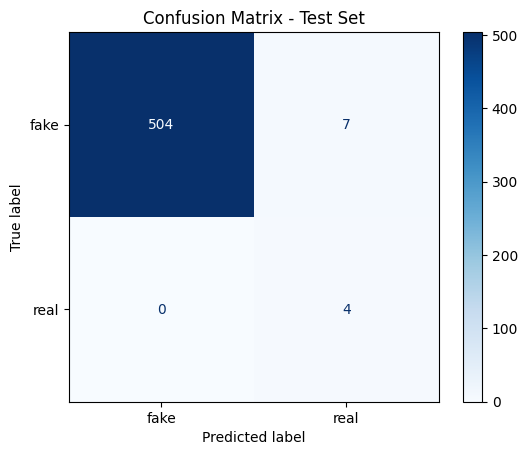

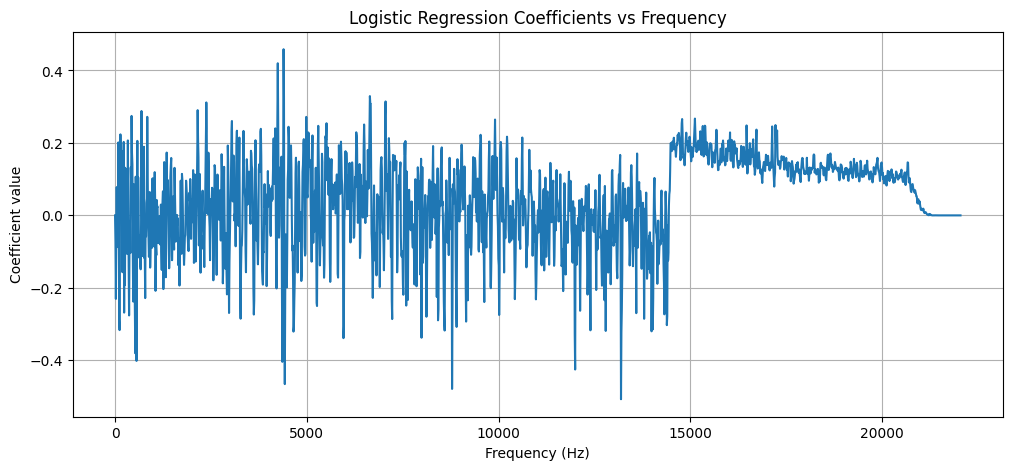

In [14]:
# Print the accuracy for the test set
test_acc = accuracy_score(y_test_aligned, y_pred_aligned)
print(f"\nTest set accuracy: {test_acc*100:.2f}%")

# Plot the confusion matrix
cm = confusion_matrix(y_test_aligned, y_pred_aligned)
disp = ConfusionMatrixDisplay(cm, display_labels=['fake', 'real'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Test Set")
plt.show()



coefficients = clf.coef_[0]  # logistic regression coefficients
N = coefficients.shape[0]    # number of frequency bins
frequencies = np.arange(N) * Fs / N  # convert bin index to Hz
plt.figure(figsize=(12, 5))
plt.plot(frequencies, coefficients)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Coefficient value")
plt.title("Logistic Regression Coefficients vs Frequency")
plt.grid(True)
plt.show()